In [1]:
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)

BASE = Path.cwd()
GOLD_DIR = BASE / "medallion" / "gold"

fop = pd.read_parquet(GOLD_DIR / "gold_first_order_products.parquet")

print(fop.shape)
display(fop.head())

(26441, 19)


,customer_id,order_id,processed_at,country_code,channel,variant_sku,product_category,line_title,variant_title,product_title,variant_grams,quantity,unit_price,line_discount,line_total,has_sku,repeat_purchase_90d,days_to_second_order,category_source
0,6423777902847,4992746586367,2020-12-30 19:27:50+00:00,sg,DTC,NaN,BET,"Better Whey - 500g Pack, Chocolate Dinosaur",NaN,NaN,NaN,1.0,22.15,0.0,22.15,False,False,NaN,inferred
1,6423777902847,4992746586367,2020-12-30 19:27:50+00:00,sg,DTC,NaN,CAP,Green Tea Extract Capsules - 60 Capsules,NaN,NaN,NaN,1.0,13.50,0.0,13.50,False,False,NaN,inferred
2,6423777902847,4992746586367,2020-12-30 19:27:50+00:00,sg,DTC,NaN,BET,"Better Whey - 500g Pack, Mango",NaN,NaN,NaN,1.0,22.15,0.0,22.15,False,False,NaN,inferred
3,6423777902847,4992746586367,2020-12-30 19:27:50+00:00,sg,DTC,NaN,CAP,L-Carnitine,NaN,NaN,NaN,1.0,25.50,0.0,25.50,False,False,NaN,inferred
4,6328286576895,4992746684671,2020-12-29 01:49:45+00:00,sg,DTC,NaN,BET,"Better Whey - 1KG Pack, Teh Tarik",NaN,NaN,NaN,1.0,33.24,0.0,33.24,False,True,0.0,inferred


In [3]:
# One row per customer for the baseline
customer_level = (
    fop[["customer_id", "repeat_purchase_90d"]]
    .drop_duplicates(subset=["customer_id"])
)

baseline_repeat_rate = customer_level["repeat_purchase_90d"].mean()

print(f"Baseline 90-day repeat rate: {baseline_repeat_rate:.2%}")

Baseline 90-day repeat rate: 21.82%


In [4]:
# One customer can appear once per category if their first order included multiple categories
category_customer = (
    fop[["customer_id", "product_category", "repeat_purchase_90d"]]
    .dropna(subset=["product_category"])
    .drop_duplicates(subset=["customer_id", "product_category"])
)

category_summary = (
    category_customer
    .groupby("product_category")
    .agg(
        first_order_customers=("customer_id", "nunique"),
        repeat_90d_customers=("repeat_purchase_90d", "sum"),
        repeat_rate_90d=("repeat_purchase_90d", "mean")
    )
    .reset_index()
)

category_summary["baseline_repeat_rate"] = baseline_repeat_rate
category_summary["repeat_rate_diff_vs_baseline"] = (
    category_summary["repeat_rate_90d"] - category_summary["baseline_repeat_rate"]
)

category_summary = category_summary.sort_values(
    ["repeat_rate_diff_vs_baseline", "first_order_customers"],
    ascending=[False, False]
)

display(category_summary)

,product_category,first_order_customers,repeat_90d_customers,repeat_rate_90d,baseline_repeat_rate,repeat_rate_diff_vs_baseline
2,BND,1562,434,0.277849,0.218221,0.059628
5,COL,1318,348,0.264036,0.218221,0.045815
3,CAP,884,219,0.247738,0.218221,0.029516
1,BET,4378,1084,0.247602,0.218221,0.029381
10,PRI,696,171,0.245690,0.218221,0.027469
9,PLT,2157,516,0.239221,0.218221,0.021000
0,ACC,3089,708,0.229200,0.218221,0.010979
6,CRE,865,194,0.224277,0.218221,0.006056
8,LEAN,2648,567,0.214124,0.218221,-0.004097
11,SOY,832,169,0.203125,0.218221,-0.015096


In [5]:
sku_customer = (
    fop[["customer_id", "variant_sku", "product_category", "product_title", "repeat_purchase_90d"]]
    .dropna(subset=["variant_sku"])
    .drop_duplicates(subset=["customer_id", "variant_sku"])
)

sku_summary = (
    sku_customer
    .groupby(["variant_sku", "product_category"])
    .agg(
        first_order_customers=("customer_id", "nunique"),
        repeat_90d_customers=("repeat_purchase_90d", "sum"),
        repeat_rate_90d=("repeat_purchase_90d", "mean"),
        example_product_title=("product_title", "first")
    )
    .reset_index()
)

sku_summary["baseline_repeat_rate"] = baseline_repeat_rate
sku_summary["repeat_rate_diff_vs_baseline"] = (
    sku_summary["repeat_rate_90d"] - sku_summary["baseline_repeat_rate"]
)

# Optional: avoid tiny sample sizes
sku_summary_filtered = sku_summary[sku_summary["first_order_customers"] >= 20].copy()

sku_summary_filtered = sku_summary_filtered.sort_values(
    ["repeat_rate_diff_vs_baseline", "first_order_customers"],
    ascending=[False, False]
)

display(sku_summary_filtered.head(20))

,variant_sku,product_category,first_order_customers,repeat_90d_customers,repeat_rate_90d,example_product_title,baseline_repeat_rate,repeat_rate_diff_vs_baseline
10,CAP-OMG-BOTTLE-V1,CAP,72,22,0.305556,SUPER OMEGA 3 CAPSULES,0.218221,0.087334
22,CRE-UNF-5G-10PK-V1,CRE,40,12,0.300000,CREATINE MONOHYDRATE SINGLE SERVE,0.218221,0.081779
40,PRI-UNF-1KG-V1,PRI,117,35,0.299145,PRIME WHEY ISOLATE,0.218221,0.080924
32,LEAN-TAR-40G-5PK-V1,LEAN,83,23,0.277108,Lean Protein Single Serve,0.218221,0.058887
24,CRE-UNF-5G-V1,CRE,27,7,0.259259,CREATINE MONOHYDRATE SINGLE SERVE,0.218221,0.041038
20,COL-UNF-300G-V1,COL,656,169,0.257622,COLLAGEN GLOW,0.218221,0.039401
0,ACC-GFB-V1,ACC,20,5,0.250000,LP Gifting Box,0.218221,0.031779
19,COL-UNF-10G-V1,COL,33,8,0.242424,Collagen Glow Single Serve,0.218221,0.024203
8,CAP-GTE-BOTTLE-V1,CAP,78,18,0.230769,GREEN TEA EXTRACT CAPSULES,0.218221,0.012548
9,CAP-MUL-BOTTLE-V1,CAP,22,5,0.227273,MULTIVITAMIN CAPSULES,0.218221,0.009052


In [6]:
"""Code to get the bar charts for visual based comparaison """
import matplotlib.pyplot as plt
import pandas as pd

# Optional: set minimum sample size for SKU chart reliability
MIN_CUSTOMERS = 20

# Use filtered SKU table if it exists, otherwise create it
sku_plot_data = sku_summary.copy()
sku_plot_data = sku_plot_data[sku_plot_data["first_order_customers"] >= MIN_CUSTOMERS].copy()

# Convert decimals into percentages for easier chart reading
sku_plot_data["repeat_rate_90d_pct"] = sku_plot_data["repeat_rate_90d"] * 100
sku_plot_data["baseline_repeat_rate_pct"] = sku_plot_data["baseline_repeat_rate"] * 100
sku_plot_data["repeat_rate_diff_vs_baseline_pp"] = sku_plot_data["repeat_rate_diff_vs_baseline"] * 100

category_plot_data = category_summary.copy()
category_plot_data["repeat_rate_90d_pct"] = category_plot_data["repeat_rate_90d"] * 100
category_plot_data["baseline_repeat_rate_pct"] = category_plot_data["baseline_repeat_rate"] * 100
category_plot_data["repeat_rate_diff_vs_baseline_pp"] = category_plot_data["repeat_rate_diff_vs_baseline"] * 100

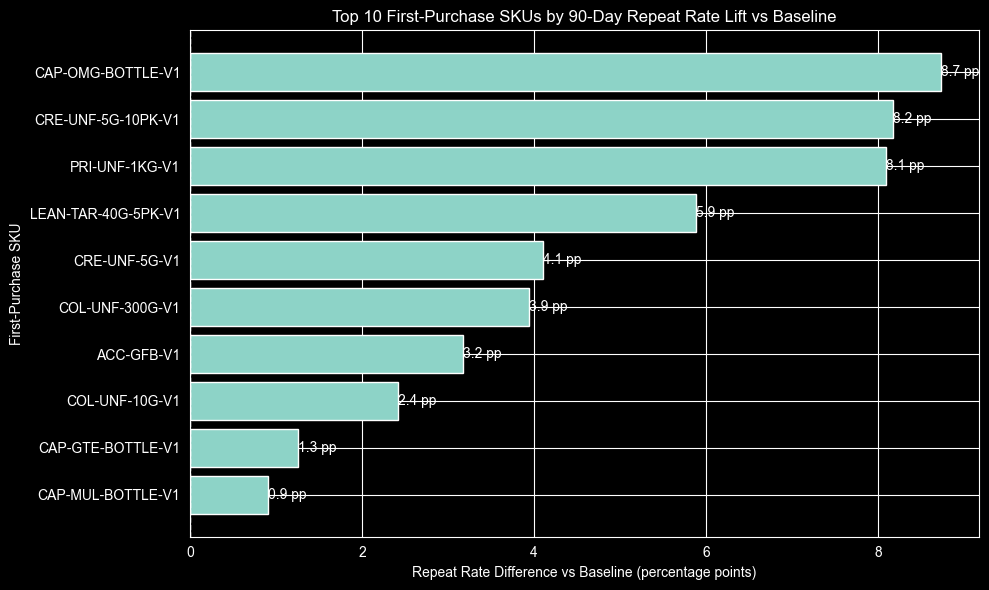

In [7]:
top_sku_lift = (
    sku_plot_data
    .sort_values("repeat_rate_diff_vs_baseline_pp", ascending=False)
    .head(10)
    .sort_values("repeat_rate_diff_vs_baseline_pp", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(top_sku_lift["variant_sku"], top_sku_lift["repeat_rate_diff_vs_baseline_pp"])

plt.xlabel("Repeat Rate Difference vs Baseline (percentage points)")
plt.ylabel("First-Purchase SKU")
plt.title("Top 10 First-Purchase SKUs by 90-Day Repeat Rate Lift vs Baseline")

plt.axvline(0, linestyle="--", linewidth=1)

for index, value in enumerate(top_sku_lift["repeat_rate_diff_vs_baseline_pp"]):
    plt.text(value, index, f"{value:.1f} pp", va="center")

plt.tight_layout()
plt.show()

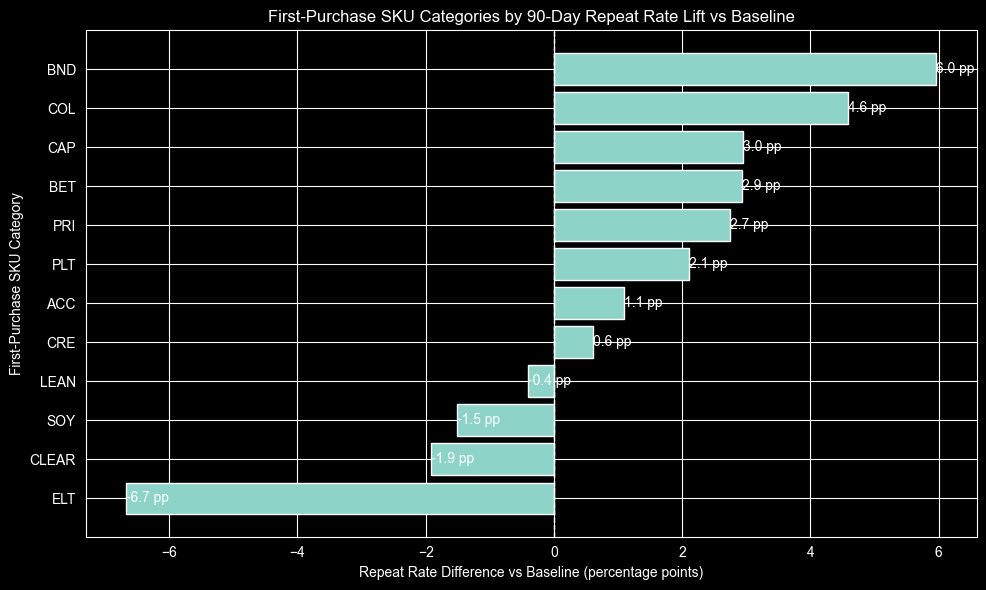

In [8]:
category_lift = (
    category_plot_data
    .sort_values("repeat_rate_diff_vs_baseline_pp", ascending=False)
    .sort_values("repeat_rate_diff_vs_baseline_pp", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(category_lift["product_category"], category_lift["repeat_rate_diff_vs_baseline_pp"])

plt.xlabel("Repeat Rate Difference vs Baseline (percentage points)")
plt.ylabel("First-Purchase SKU Category")
plt.title("First-Purchase SKU Categories by 90-Day Repeat Rate Lift vs Baseline")

plt.axvline(0, linestyle="--", linewidth=1)

for index, value in enumerate(category_lift["repeat_rate_diff_vs_baseline_pp"]):
    plt.text(value, index, f"{value:.1f} pp", va="center")

plt.tight_layout()
plt.show()

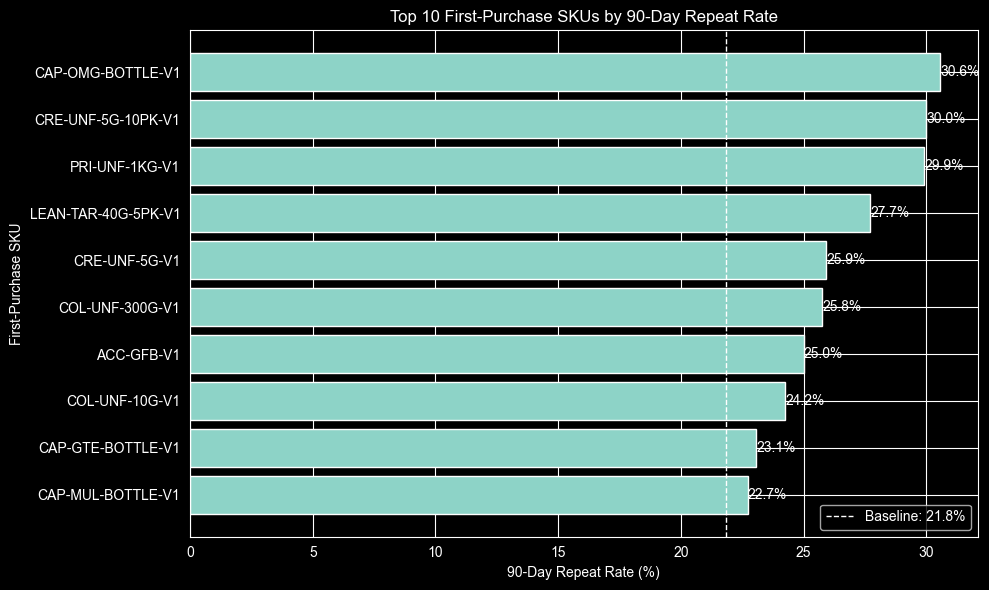

In [9]:
top_sku_repeat_rate = (
    sku_plot_data
    .sort_values("repeat_rate_90d_pct", ascending=False)
    .head(10)
    .sort_values("repeat_rate_90d_pct", ascending=True)
)

baseline_pct = baseline_repeat_rate * 100

plt.figure(figsize=(10, 6))
plt.barh(top_sku_repeat_rate["variant_sku"], top_sku_repeat_rate["repeat_rate_90d_pct"])

plt.xlabel("90-Day Repeat Rate (%)")
plt.ylabel("First-Purchase SKU")
plt.title("Top 10 First-Purchase SKUs by 90-Day Repeat Rate")

plt.axvline(baseline_pct, linestyle="--", linewidth=1, label=f"Baseline: {baseline_pct:.1f}%")
plt.legend()

for index, value in enumerate(top_sku_repeat_rate["repeat_rate_90d_pct"]):
    plt.text(value, index, f"{value:.1f}%", va="center")

plt.tight_layout()
plt.show()

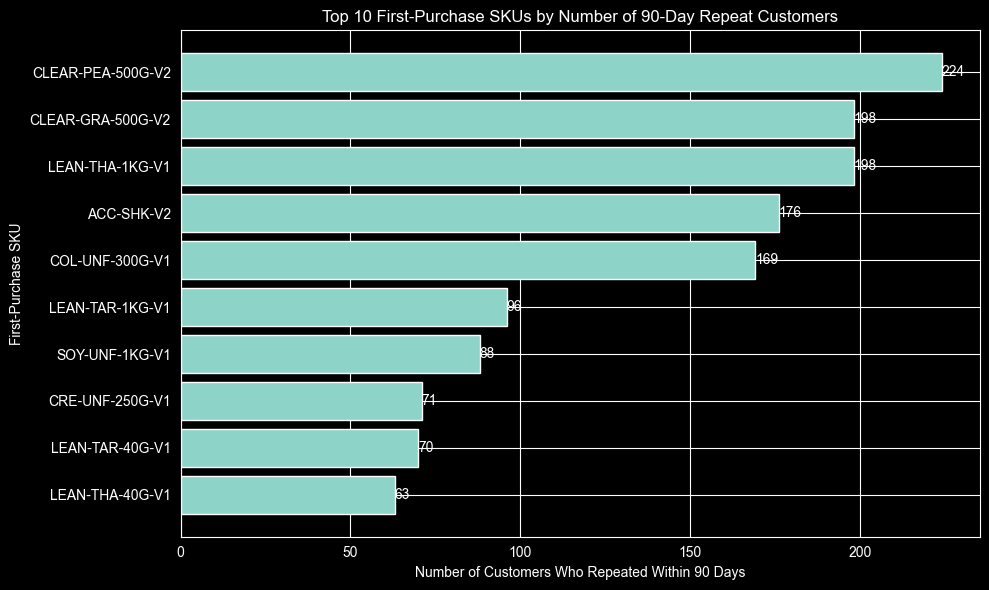

In [10]:
top_sku_repeat_customers = (
    sku_plot_data
    .sort_values("repeat_90d_customers", ascending=False)
    .head(10)
    .sort_values("repeat_90d_customers", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(top_sku_repeat_customers["variant_sku"], top_sku_repeat_customers["repeat_90d_customers"])

plt.xlabel("Number of Customers Who Repeated Within 90 Days")
plt.ylabel("First-Purchase SKU")
plt.title("Top 10 First-Purchase SKUs by Number of 90-Day Repeat Customers")

for index, value in enumerate(top_sku_repeat_customers["repeat_90d_customers"]):
    plt.text(value, index, f"{int(value)}", va="center")

plt.tight_layout()
plt.show()